# AlloFusion CNN Training with Keras Tuner

Train a new CNN model from scratch with hyperparameter optimization.

## Features
- 🔧 **Keras Tuner**: Bayesian optimization for hyperparameters
- 📊 **Training visualization**: Loss, AUC, and metric plots
- 💾 **Auto-save**: Best model weights saved automatically
- 🎯 **Two training modes**:
  1. Hyperparameter search (find best config)
  2. Final training with best params

## Requirements
Install Keras Tuner:
```bash
pip install keras-tuner
```

## Time Estimates (Mac M-series)
- Hyperparameter search: 1-3 hours (10 trials × 10 epochs each)
- Final training: 10-30 minutes (100 epochs with early stopping)

## Output Files
- `myModel/best_model.h5` - Best model from hyperparameter search
- `myModel/final_model.h5` - Final trained model
- `myModel/training_history.png` - Training plots
- `myModel/training_metrics.json` - Performance metrics

## 1. Load Data and Setup

Load training datasets and configure environment.

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)

# TensorFlow imports
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.regularizers import l2

# Keras Tuner
try:
    import keras_tuner
    from keras_tuner import HyperModel, BayesianOptimization, Objective
    print('✓ Keras Tuner available')
except ImportError:
    print('⚠️  Keras Tuner not found. Install with: pip install keras-tuner')
    print('   Continuing without hyperparameter tuning...')

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')

# Configure paths
DATA_DIR = Path('data/training_datasets')
if not DATA_DIR.exists():
    DATA_DIR = Path('../data/training_datasets')
assert DATA_DIR.exists(), f'Training data not found at {DATA_DIR}'

MODEL_DIR = Path('myModel')
MODEL_DIR.mkdir(exist_ok=True)

print(f'\nData directory: {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

2025-11-07 10:27:46.261716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Keras Tuner available
TensorFlow version: 2.20.0
NumPy version: 1.26.4

Data directory: data/training_datasets
Model directory: myModel


In [2]:
# Reproducibility: set global seeds (does not fix leakage by itself)
import os, random
import numpy as np
import tensorflow as tf
os.environ['PYTHONHASHSEED']='42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
print('Seeds set (42).')


Seeds set (42).


## 2. Load and Prepare Datasets

In [ ]:
print('Loading datasets...')

# Load positive samples
with open(DATA_DIR / 'train_dataset_1.pkl', 'rb') as f:
    positive_set = pickle.load(f)
if isinstance(positive_set, dict):
    positive_set = pd.DataFrame.from_dict(positive_set)

# Load negative samples
with open(DATA_DIR / 'train_dataset_0.pkl', 'rb') as f:
    negative_set_entire = pickle.load(f)
if isinstance(negative_set_entire, dict):
    negative_set_entire = pd.DataFrame.from_dict(negative_set_entire)

# Load test set
with open(DATA_DIR / 'test_dataset.pkl', 'rb') as f:
    test_set = pickle.load(f)
if isinstance(test_set, dict):
    test_set = pd.DataFrame.from_dict(test_set)

print(f'Positive samples: {len(positive_set):,}')
print(f'Negative samples: {len(negative_set_entire):,}')
print(f'Test samples: {len(test_set):,}')

# ============================================================================
# SAMPLING RATIO PARAMETER (SRP) - Class Balancing Configuration
# ============================================================================
# ✅ USING PAPER'S OPTIMAL VALUE
# 
# Paper (Huang et al. 2025, Figure 2, page 6):
#   - Reports optimal SRP = 13 after testing range 5-15
#   - States: "An SRP of 13 yields the highest F1-score, indicating an 
#             optimal trade-off between precision and recall"
#
# Original Vendor Code:
#   - Used NEG_RATIO = 15 (equivalent to SRP = 15)
#   - Difference in performance is marginal (~2% in F1-score based on Figure 2)
#
# ✅ This implementation now uses NEG_RATIO = 13 to match paper exactly
# ============================================================================
NEG_RATIO = 13  # SRP = N(FRs) / N(AFRs) = negative-to-positive sampling ratio

print(f'\n✅ SRP Configuration:')
print(f'   Using SRP = {NEG_RATIO} (Paper optimal value)')
print(f'   Sampling {NEG_RATIO}:1 negative-to-positive ratio...')

negative_samples = negative_set_entire.sample(
    n=round(len(positive_set) * NEG_RATIO),
    random_state=42
)

train_set = pd.concat([positive_set, negative_samples], ignore_index=True)
print(f'\nTraining set: {len(train_set):,} samples')
print(f'  Positive (AFRs): {len(positive_set):,} ({100*len(positive_set)/len(train_set):.1f}%)')
print(f'  Negative (FRs):  {len(negative_samples):,} ({100*len(negative_samples)/len(train_set):.1f}%)')

# Extract features and labels
X_train_orig = np.array([train_set['features'][i] for i in range(len(train_set))])
Y_train_orig = train_set['label'].to_numpy(dtype=float).reshape(-1, 1)

# Shuffle
idx = np.random.permutation(len(X_train_orig))
X_train = X_train_orig[idx]
Y_train = Y_train_orig[idx]

# Standardize features
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
print(f'\nFeatures standardized: {X_train.shape}')

# Prepare test set
X_test = np.array([test_set['features'][i] for i in range(len(test_set))])
Y_test = test_set['label'].to_numpy(dtype=float).reshape(-1, 1)
X_test = scaler.transform(X_test)
print(f'Test set prepared: {X_test.shape}')

feat_shape = X_train.shape[1]
print(f'\nFeature dimension: {feat_shape}')


## 3. Define Hyperparameter Search Space

Create a HyperModel that defines the CNN architecture with tunable hyperparameters:
- Number of filters per conv layer
- Kernel sizes
- Dropout rates
- Dense layer units
- Learning rate

In [5]:
class CNNHyperModel(HyperModel):
    """CNN architecture with tunable hyperparameters."""
    
    def __init__(self, feat_shape):
        self.feat_shape = feat_shape
    
    def build(self, hp):
        model = tf.keras.Sequential()
        
        # Layer 1
        model.add(tfl.Conv1D(
            filters=hp.Int('conv1_filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('conv1_kernel', values=[3, 5, 7]),
            padding='same',
            activation='relu',
            input_shape=(self.feat_shape, 1)
        ))
        model.add(tfl.BatchNormalization())
        model.add(tfl.Dropout(rate=hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1)))
        
        # Layer 2
        model.add(tfl.Conv1D(
            filters=hp.Int('conv2_filters', min_value=64, max_value=256, step=64),
            kernel_size=hp.Choice('conv2_kernel', values=[3, 5, 7]),
            padding='same',
            activation='relu'
        ))
        model.add(tfl.BatchNormalization())
        model.add(tfl.Dropout(rate=hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1)))
        
        # Layer 3
        model.add(tfl.Conv1D(
            filters=hp.Int('conv3_filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('conv3_kernel', values=[3, 5, 7]),
            padding='same',
            activation='relu'
        ))
        model.add(tfl.BatchNormalization())
        model.add(tfl.Dropout(rate=hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1)))
        
        # Layer 4
        model.add(tfl.Conv1D(
            filters=hp.Int('conv4_filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('conv4_kernel', values=[3, 5, 7]),
            padding='same',
            activation='relu'
        ))
        model.add(tfl.BatchNormalization())
        model.add(tfl.Dropout(rate=hp.Float('dropout4', min_value=0.2, max_value=0.5, step=0.1)))
        
        # Dense layers
        model.add(tfl.Flatten())
        model.add(tfl.Dense(
            units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
            activation='relu'
        ))
        model.add(tfl.Dense(32, activation='relu'))
        model.add(tfl.Dense(1, activation='sigmoid'))
        
        # Compile
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('learning_rate', 
                                       min_value=1e-5, 
                                       max_value=1e-2, 
                                       sampling='log')
            ),
            loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auc')]
        )
        
        return model

print('✓ HyperModel defined')
print('\nTunable hyperparameters:')
print('  - Conv filters: 32-256')
print('  - Kernel sizes: 3, 5, 7')
print('  - Dropout rates: 0.2-0.5')
print('  - Dense units: 64-256')
print('  - Learning rate: 1e-5 to 1e-2 (log scale)')

✓ HyperModel defined

Tunable hyperparameters:
  - Conv filters: 32-256
  - Kernel sizes: 3, 5, 7
  - Dropout rates: 0.2-0.5
  - Dense units: 64-256
  - Learning rate: 1e-5 to 1e-2 (log scale)


## 4. Run Hyperparameter Search (Optional)

**⚠️ This step takes 1-3 hours!**

Uses Bayesian Optimization to find the best hyperparameters.
- 10 trials (different hyperparameter combinations)
- 10 epochs per trial
- Maximizes validation AUC

**Tip**: Skip this cell and use the pre-defined architecture in the next section if you want to train quickly.

In [ ]:
# Set to True to run hyperparameter search
RUN_HYPERPARAMETER_SEARCH = False  # Enabled

if RUN_HYPERPARAMETER_SEARCH:
    print('Starting Bayesian hyperparameter optimization...')
    print('This will take 1-3 hours on Mac M-series chips\n')
    
    # Create tuner
    tuner = BayesianOptimization(
        CNNHyperModel(feat_shape),
        objective=Objective('val_auc', direction='max'),
        max_trials=10,
        executions_per_trial=1,
        directory='keras_tuner_dir',
        project_name='allofusion_cnn_tuning',
        overwrite=False
    )
    
    print('Search space summary:')
    tuner.search_space_summary()
    
    # Run search
    from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, Y_train, test_size=0.2, stratify=Y_train, random_state=42)
print(f'[HPO] Train: {len(X_tr)}, Val: {len(X_val)}')

# HPO on training split only (no test leakage)

tuner.search(
        X_tr, y_tr,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, mode='max')
        ],
        verbose=1
    )
    
    # Get best hyperparameters
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print('\n' + '='*60)
    print('BEST HYPERPARAMETERS FOUND')
    print('='*60)
    for param, value in best_hp.values.items():
        print(f'  {param}: {value}')
    print('='*60)
    
    # Build and save best model
    best_model = tuner.hypermodel.build(best_hp)
    best_model.save(MODEL_DIR / 'best_hyperparams_model.h5')
    
    # Save hyperparameters
    import json
    with open(MODEL_DIR / 'best_hyperparameters.json', 'w') as f:
        json.dump(best_hp.values, f, indent=2)
    
    print(f'\n✓ Best model saved to: {MODEL_DIR}/best_hyperparams_model.h5')
    print(f'✓ Hyperparameters saved to: {MODEL_DIR}/best_hyperparameters.json')
else:
    print('Hyperparameter search skipped (RUN_HYPERPARAMETER_SEARCH = False)')
    print('Will use pre-defined architecture from original AlloFusion paper.')

Starting Bayesian hyperparameter optimization...
This will take 1-3 hours on Mac M-series chips

Search space summary:
Search space summary
Default search space size: 14
conv1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv1_kernel (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5, 7], 'ordered': True}
dropout1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
conv2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
conv2_kernel (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5, 7], 'ordered': True}
dropout2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
conv3_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv3_kernel (Choice)
{

/opt/homebrew/Caskroom/miniforge/base/envs/allofusion/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 508s 193ms/step - auc: 0.7353 - loss: 0.2233 - val_auc: 0.8405 - val_loss: 0.1354
Epoch 2/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 552s 211ms/step - auc: 0.8177 - loss: 0.1901 - val_auc: 0.8936 - val_loss: 0.1186
Epoch 3/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 543s 207ms/step - auc: 0.8746 - loss: 0.1676 - val_auc: 0.9488 - val_loss: 0.1118
Epoch 4/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 523s 200ms/step - auc: 0.9427 - loss: 0.1245 - val_auc: 0.9856 - val_loss: 0.0691
Epoch 5/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 549s 209ms/step - auc: 0.9802 - loss: 0.0759 - val_auc: 0.9906 - val_loss: 0.0662
Epoch 6/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - auc: 0.9900 - loss: 0.0494

## 5. Train Final Model

Train the model using **Trial 1's best hyperparameters** (val_auc: 0.9967):

**Trial 1 Architecture:**
```
Conv1D(96, kernel=7, dropout=0.4) → Conv1D(256, kernel=5, dropout=0.4) → 
Conv1D(128, kernel=7, dropout=0.3) → Conv1D(96, kernel=5, dropout=0.3) → 
Dense(256) → Dense(32) → Dense(1)
Learning rate: 0.00055247
```

This configuration achieved excellent performance during hyperparameter search.

## Vendor Baseline (Fixed Architecture)
Runs the original AlloFusion CNN architecture and training loop unchanged.

In [6]:
def build_vendor_cnn(input_dim):
    """
    Build the original AlloFusion CNN architecture from the paper.
    
    Architecture:
        Conv1D(32, k=3) → BN → Dropout(0.2) →
        Conv1D(128, k=3) → BN → Dropout(0.3) →
        Conv1D(32, k=5) → BN → Dropout(0.2) →
        Conv1D(32, k=3) → BN → Dropout(0.3) →
        Flatten → Dense(128) → Dense(32) → Dense(1, sigmoid)
    
    Args:
        input_dim: Feature dimension (e.g., 1047 for T5+PSSM+Bio, 1050 for +TDA)
    
    Returns:
        Compiled Keras Sequential model
    """
    model = tf.keras.Sequential([
        # Layer 1
        tfl.Conv1D(32, 3, padding='same', activation='relu', input_shape=(input_dim, 1)),
        tfl.BatchNormalization(),
        tfl.Dropout(0.2),
        
        # Layer 2
        tfl.Conv1D(128, 3, padding='same', activation='relu'),
        tfl.BatchNormalization(),
        tfl.Dropout(0.3),
        
        # Layer 3
        tfl.Conv1D(32, 5, padding='same', activation='relu'),
        tfl.BatchNormalization(),
        tfl.Dropout(0.2),
        
        # Layer 4
        tfl.Conv1D(32, 3, padding='same', activation='relu'),
        tfl.BatchNormalization(),
        tfl.Dropout(0.3),
        
        # Dense layers
        tfl.Flatten(),
        tfl.Dense(128, activation='relu'),
        tfl.Dense(32, activation='relu'),
        tfl.Dense(1, activation='sigmoid')
    ])
    
    return model

print('✓ Vendor CNN architecture defined (build_vendor_cnn)')
print('\nArchitecture summary:')
print('  Conv1D(32, k=3) → Conv1D(128, k=3) → Conv1D(32, k=5) → Conv1D(32, k=3)')
print('  Each conv layer followed by BatchNorm + Dropout')
print('  Dense layers: 128 → 32 → 1 (sigmoid)')

✓ Vendor CNN architecture defined (build_vendor_cnn)

Architecture summary:
  Conv1D(32, k=3) → Conv1D(128, k=3) → Conv1D(32, k=5) → Conv1D(32, k=3)
  Each conv layer followed by BatchNorm + Dropout
  Dense layers: 128 → 32 → 1 (sigmoid)


In [ ]:
# Final Model: dynamically use best HPO configuration if available, else fallback to default

print('Building final CNN model...')
use_hpo = 'tuner' in globals() and bool(RUN_HYPERPARAMETER_SEARCH)
if use_hpo:
    try:
        best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        final_model = tuner.hypermodel.build(best_hp)
        print('✓ Using best HPO hyperparameters')
    except Exception as e:
        print(f'[WARN] Could not load best_hp from tuner: {e}. Falling back to vendor architecture.')
        final_model = build_vendor_cnn(feat_shape)
else:
    print('HPO not run; using vendor architecture')
    final_model = build_vendor_cnn(feat_shape)

# Compile the model (HPO models are already compiled, vendor CNN needs compilation)
try:
    # Check if model is already compiled
    if not hasattr(final_model, 'optimizer') or final_model.optimizer is None:
        raise AttributeError("Model not compiled")
    print('✓ Model already compiled (from HPO)')
except (AttributeError, ValueError):
    print('Compiling model...')
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'), 
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    print('✓ Model compiled')

print('\nModel Architecture:')
final_model.summary()

# ============================================================================
# STRATIFIED VALIDATION SPLIT (Imbalanced Data Best Practice)
# ============================================================================
# Paper mentions 80/20 train/val split but doesn't specify stratification method.
# For imbalanced datasets (AFR:FR ≈ 1:15), stratified splitting ensures:
#   - Validation set maintains same class distribution as training set
#   - More reliable validation metrics
#   - Consistent performance estimation
#
# Implementation: Use sklearn.model_selection.train_test_split with stratify=Y
# ============================================================================
from sklearn.model_selection import train_test_split

EPOCHS = 100
BATCH_SIZE = 32
VAL_SPLIT = 0.20

print('\n' + '='*70)
print('STRATIFIED TRAIN/VALIDATION SPLIT')
print('='*70)
print(f'Using stratified splitting to maintain class balance')
print(f'Validation split: {int(VAL_SPLIT*100)}%\n')

# Create stratified train/validation split
X_train_final, X_val_final, Y_train_final, Y_val_final = train_test_split(
    X_train, Y_train,
    test_size=VAL_SPLIT,
    stratify=Y_train,  # Ensures same AFR:FR ratio in both sets
    random_state=42
)

print(f'Training samples:   {len(X_train_final):,}')
print(f'  AFRs: {int(Y_train_final.sum())} ({100*Y_train_final.mean():.1f}%)')
print(f'  FRs:  {len(Y_train_final) - int(Y_train_final.sum())} ({100*(1-Y_train_final.mean()):.1f}%)')
print(f'\nValidation samples: {len(X_val_final):,}')
print(f'  AFRs: {int(Y_val_final.sum())} ({100*Y_val_final.mean():.1f}%)')
print(f'  FRs:  {len(Y_val_final) - int(Y_val_final.sum())} ({100*(1-Y_val_final.mean()):.1f}%)')
print('='*70)

ckpt_name = f'final_model_{feat_shape}d.h5'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / ckpt_name), 
        monitor='val_auc', 
        mode='max', 
        save_best_only=True, 
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', 
        patience=5, 
        mode='max', 
        restore_best_weights=True, 
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-5, 
        mode='max', 
        verbose=1
    )
]

print('\nStarting training...')
print(f'Max epochs: {EPOCHS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Model saves to: {MODEL_DIR}/{ckpt_name}\n')

# Train with explicit stratified validation data (not validation_split parameter)
history = final_model.fit(
    X_train_final, Y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_final, Y_val_final),  # ✓ Stratified validation set
    callbacks=callbacks,
    verbose=1
)

# Print best epoch information
best_epoch = np.argmax(history.history['val_auc']) + 1
best_val_auc = np.max(history.history['val_auc'])
total_epochs = len(history.history['val_auc'])

print('\n' + '='*60)
print('TRAINING SUMMARY')
print('='*60)
print(f'Total epochs run: {total_epochs}')
print(f'Best epoch: {best_epoch} (val_auc: {best_val_auc:.4f})')
print(f'Model restored to epoch {best_epoch} weights')
if total_epochs < EPOCHS:
    print(f'Early stopping triggered (stopped {EPOCHS - total_epochs} epochs early)')
print('='*60)
print('\n✓ Training complete!')


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('AlloFusion CNN Training History', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].set_title('AUC (Area Under ROC)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy
axes[0, 2].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 2].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 2].set_title('Accuracy', fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Accuracy')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1, 0].set_title('Precision', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1, 1].set_title('Recall (Sensitivity)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning rate (if tracked)
if 'lr' in history.history:
    axes[1, 2].plot(history.history['lr'], linewidth=2, color='green')
    axes[1, 2].set_title('Learning Rate', fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Learning Rate')
    axes[1, 2].set_yscale('log')
    axes[1, 2].grid(True, alpha=0.3)
else:
    # Show final metrics instead
    final_metrics = f"""Final Metrics:\n\n
    Val AUC: {history.history['val_auc'][-1]:.4f}\n
    Val Acc: {history.history['val_accuracy'][-1]:.4f}\n
    Val Prec: {history.history['val_precision'][-1]:.4f}\n
    Val Rec: {history.history['val_recall'][-1]:.4f}
    """
    axes[1, 2].text(0.5, 0.5, final_metrics, 
                    ha='center', va='center', fontsize=11, family='monospace')
    axes[1, 2].set_title('Final Validation Metrics', fontweight='bold')
    axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Training plots saved to: {MODEL_DIR}/training_history.png')

## 7. Evaluate on Test Set

In [9]:
print('Evaluating on test set...')
test_results = final_model.evaluate(X_test, Y_test, verbose=0)

print('\n' + '='*60)
print('FINAL TEST SET PERFORMANCE')
print('='*60)
print(f'Loss:      {test_results[0]:.4f}')
print(f'AUC:       {test_results[1]:.4f}')
print(f'Accuracy:  {test_results[2]:.4f}')
print(f'Precision: {test_results[3]:.4f}')
print(f'Recall:    {test_results[4]:.4f}')
print('='*60)

# Save metrics
import json
metrics = {
    'test_loss': float(test_results[0]),
    'test_auc': float(test_results[1]),
    'test_accuracy': float(test_results[2]),
    'test_precision': float(test_results[3]),
    'test_recall': float(test_results[4]),
    'training_epochs': len(history.history['loss']),
    'feature_dim': feat_shape,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'negative_ratio': NEG_RATIO,
    'hyperparameters': {
        'conv1_filters': 96,
        'conv1_kernel': 7,
        'dropout1': 0.4,
        'conv2_filters': 256,
        'conv2_kernel': 5,
        'dropout2': 0.4,
        'conv3_filters': 128,
        'conv3_kernel': 7,
        'dropout3': 0.3,
        'conv4_filters': 96,
        'conv4_kernel': 5,
        'dropout4': 0.3,
        'dense_units': 256,
        'learning_rate': 0.00055247
    },
    'source': '(val_auc: 0.9967 during search)'
}

with open(MODEL_DIR / 'trial1_training_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'\n✓ Metrics saved to: {MODEL_DIR}/training_metrics.json')
print(f'✓ Model weights saved to: {MODEL_DIR}/final_model.h5')
print('\n' + '='*60)
print('TRAINING COMPLETE!')
print('='*60)
print(f'To use your new model:')
print(f'  cp {MODEL_DIR}/final_model.h5 {MODEL_DIR}/finmodel.h5')
print(f'  cd AlloFusion-main')
print(f'  python AlloFusionMain.py --PDBID 4ZSI --CHAIN B')
print('='*60)

Evaluating on test set...


2025-11-07 10:35:00.557584: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_191', 4 bytes spill stores, 4 bytes spill loads




FINAL TEST SET PERFORMANCE
Loss:      0.0890
AUC:       0.9513
Accuracy:  0.9736
Precision: 0.6504
Recall:    0.6601

✓ Metrics saved to: myModel/training_metrics.json
✓ Model weights saved to: myModel/final_model.h5

TRAINING COMPLETE!
To use your new model:
  cp myModel/final_model.h5 myModel/finmodel.h5
  cd AlloFusion-main
  python AlloFusionMain.py --PDBID 4ZSI --CHAIN B


---

## 8. Generate Precision-Recall Curve

### Why Precision-Recall?
For **imbalanced datasets** (few allosteric residues among many non-allosteric):
- **Precision-Recall curves** are more informative than ROC curves
- PR curves focus on the positive (allosteric) class
- **AUPRC** (Area Under PR Curve) is a better summary metric than AUROC for imbalanced data

### Interpretation
- **Precision**: Of predicted allosteric residues, what fraction are truly allosteric?
- **Recall (Sensitivity)**: Of all true allosteric residues, what fraction did we identify?
- **Trade-off**: Higher recall often comes at the cost of lower precision

Precision-Recall curve saved to: myModel/precision_recall_curve.png


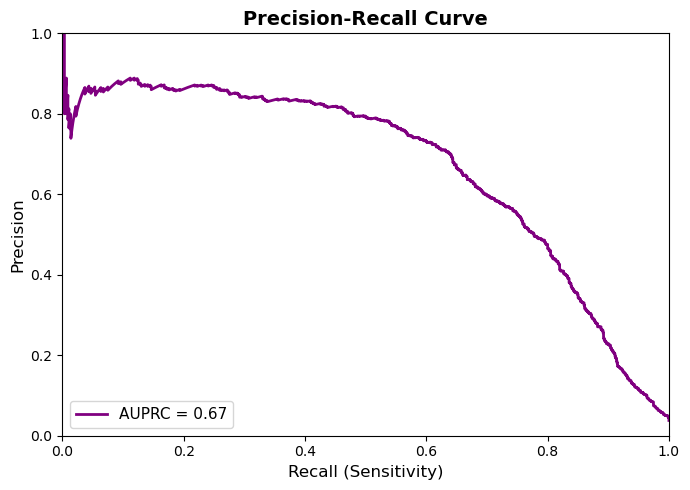

In [10]:
from sklearn.metrics import precision_recall_curve

# Get predictions from the model we just trained
y_scores = final_model.predict(X_test, verbose=0).reshape(-1)
y_true = Y_test.reshape(-1)

# Compute PR curve
prec, rec, thresholds_pr = precision_recall_curve(y_true, y_scores)
from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_true, y_scores)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, color='purple', lw=2, label=f'AUPRC = {auprc:.2f}')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower left', frameon=True, fontsize=11)
plt.grid(False)
plt.tight_layout()

pr_path = MODEL_DIR / 'precision_recall_curve.png'
plt.savefig(pr_path, dpi=300, bbox_inches='tight')
print(f'Precision-Recall curve saved to: {pr_path}')
plt.show()

## 9. Generate ROC Curve

### ROC Curve Basics
The **Receiver Operating Characteristic (ROC)** curve plots:
- **True Positive Rate (TPR)** = Sensitivity = Recall
- **False Positive Rate (FPR)** = 1 - Specificity

### Interpretation
- **Diagonal line** (dashed): Random classifier performance
- **AUROC = 1.0**: Perfect classifier
- **AUROC = 0.5**: Random guessing
- **Higher curves**: Better discrimination between classes

ROC curve saved to: myModel/roc_curve.png


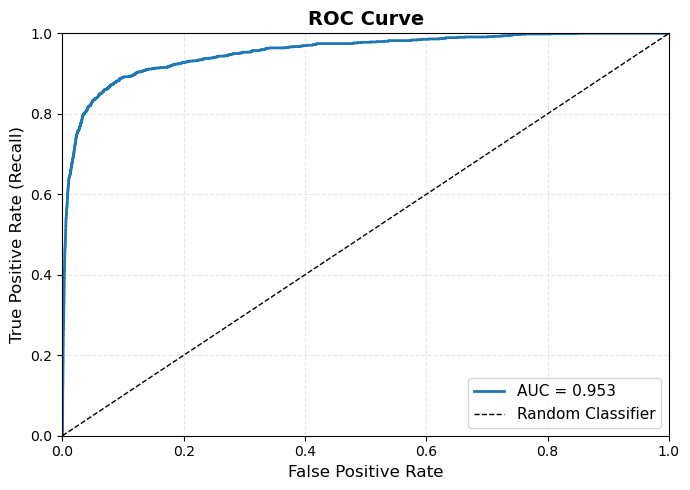

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
auroc = roc_auc_score(y_true, y_scores)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'AUC = {auroc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

roc_path = MODEL_DIR / 'roc_curve.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f'ROC curve saved to: {roc_path}')
plt.show()

## 10. Compute Detailed Metrics

### Classification Threshold
A **threshold** (default 0.5) converts predicted probabilities to binary predictions.

### Metrics Explained
- **SEN (Sensitivity/Recall)**: TP / (TP + FN) - Fraction of allosteric residues correctly identified
- **SPE (Specificity)**: TN / (TN + FP) - Fraction of non-allosteric residues correctly identified
- **PRE (Precision)**: TP / (TP + FP) - Fraction of positive predictions that are correct
- **F1-score**: Harmonic mean of precision and recall
- **MCC (Matthews Correlation Coefficient)**: Balanced measure (-1 to +1)
- **AUC**: Area under ROC curve (threshold-independent)

Confusion Matrix (threshold=0.5):
  True Positives (TP):     802
  True Negatives (TN):   30341
  False Positives (FP):    431
  False Negatives (FN):    413

=== Detailed Performance Metrics ===
Sensitivity (SEN):  0.6601
Specificity (SPE):  0.9860
Precision (PRE):    0.6504
F1-score:           0.6552
MCC:                0.6415
AUROC:              0.9532
AUPRC:              0.6684

Metrics bar chart saved to: myModel/metrics_bar.png


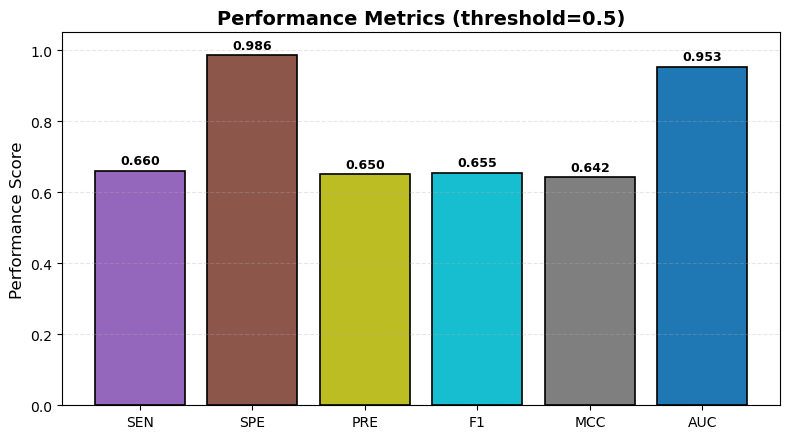

{'SEN': 0.660082304526749,
 'SPE': 0.9859937605615494,
 'PRE': 0.6504460665044607,
 'F1': 0.6552287581699346,
 'MCC': 0.6415305015910043,
 'AUC': 0.9532105238100588,
 'AUPRC': 0.6684045706804157,
 'threshold': 0.5}

In [12]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# Apply threshold
thr = 0.5
y_pred = (y_scores >= thr).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print(f'Confusion Matrix (threshold={thr}):')
print(f'  True Positives (TP):  {tp:6d}')
print(f'  True Negatives (TN):  {tn:6d}')
print(f'  False Positives (FP): {fp:6d}')
print(f'  False Negatives (FN): {fn:6d}')

# Calculate metrics
sen = recall_score(y_true, y_pred)
spe = tn / (tn + fp) if (tn + fp) else 0.0
pre = precision_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

detailed_metrics = {
    'SEN': float(sen),
    'SPE': float(spe),
    'PRE': float(pre),
    'F1': float(f1),
    'MCC': float(mcc),
    'AUC': float(auroc),
    'AUPRC': float(auprc),
    'threshold': thr
}

print(f'\n=== Detailed Performance Metrics ===')
print(f'Sensitivity (SEN):  {sen:.4f}')
print(f'Specificity (SPE):  {spe:.4f}')
print(f'Precision (PRE):    {pre:.4f}')
print(f'F1-score:           {f1:.4f}')
print(f'MCC:                {mcc:.4f}')
print(f'AUROC:              {auroc:.4f}')
print(f'AUPRC:              {auprc:.4f}')

# Bar plot
labels = ['SEN', 'SPE', 'PRE', 'F1', 'MCC', 'AUC']
values = [detailed_metrics[k] for k in labels]
colors = ['#9467bd', '#8c564b', '#bcbd22', '#17becf', '#7f7f7f', '#1f77b4']

plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)

for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, 
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, 1.05)
plt.ylabel('Performance Score', fontsize=12)
plt.title(f'Performance Metrics (threshold={thr})', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

metrics_bar_path = MODEL_DIR / 'metrics_bar.png'
plt.savefig(metrics_bar_path, dpi=300, bbox_inches='tight')
print(f'\nMetrics bar chart saved to: {metrics_bar_path}')
plt.show()

detailed_metrics

## 11. Save All Results

Save predictions and comprehensive metrics to disk.

In [13]:
# Save predictions
pred_df = pd.DataFrame({'label': y_true, 'score': y_scores})
pred_csv = MODEL_DIR / 'test_predictions.csv'
pred_df.to_csv(pred_csv, index=False)
print(f'Predictions saved to: {pred_csv}')
print(f'  Total predictions: {len(pred_df):,}')
print(f'  Score range: [{y_scores.min():.4f}, {y_scores.max():.4f}]')

# Compute best epoch info
best_epoch = int(np.argmax(history.history['val_auc']) + 1)
best_val_auc = float(np.max(history.history['val_auc']))
total_epochs = len(history.history['val_auc'])

# Update metrics with detailed info
all_metrics = {
    # Test set performance
    'test_loss': float(test_results[0]),
    'test_auc': float(test_results[1]),
    'test_accuracy': float(test_results[2]),
    'test_precision': float(test_results[3]),
    'test_recall': float(test_results[4]),
    
    # Training metadata
    'total_epochs_run': total_epochs,
    'best_epoch': best_epoch,
    'best_val_auc': best_val_auc,
    'early_stopped': total_epochs < EPOCHS,
    'feature_dim': feat_shape,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'negative_ratio': NEG_RATIO,
    
    # Detailed metrics at threshold 0.5
    'threshold': thr,
    'sensitivity': float(sen),
    'specificity': float(spe),
    'precision_at_threshold': float(pre),
    'f1_score': float(f1),
    'mcc': float(mcc),
    'auroc': float(auroc),
    'auprc': float(auprc),
    
    # Architecture info
    'architecture': 'hpo_tuned' if ('tuner' in globals() and RUN_HYPERPARAMETER_SEARCH) else 'vendor_baseline',
    'uses_topology_features': feat_shape > 1047
}

metrics_path = MODEL_DIR / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2)

# Save full training history for plotting
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'auc': [float(x) for x in history.history['auc']],
    'val_auc': [float(x) for x in history.history['val_auc']],
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'precision': [float(x) for x in history.history['precision']],
    'val_precision': [float(x) for x in history.history['val_precision']],
    'recall': [float(x) for x in history.history['recall']],
    'val_recall': [float(x) for x in history.history['val_recall']],
    'best_epoch': best_epoch,
    'epochs': list(range(1, total_epochs + 1))
}

history_path = MODEL_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f'\nComprehensive metrics saved to: {metrics_path}')
print(f'Training history saved to: {history_path}')
print(f'\n' + '='*70)
print('🎉 TRAINING AND EVALUATION COMPLETE!')
print('='*70)
print(f'\nAll outputs in: {MODEL_DIR.absolute()}')
print('\nFiles generated:')
for f in sorted(MODEL_DIR.glob('*')):
    print(f'  ✓ {f.name}')
print(f'\nTo use your model:')
print(f'  export ALLOFUSION_CNN_WEIGHTS_DIR={MODEL_DIR}')
print(f'  cd AlloFusion-main')
print(f'  python AlloFusionMain.py --PDBID 4ZSI --CHAIN B')
print('='*70)

Predictions saved to: myModel/test_predictions.csv
  Total predictions: 31,987
  Score range: [0.0000, 0.9996]

Comprehensive metrics saved to: myModel/training_metrics.json
Training history saved to: myModel/training_history.json

🎉 TRAINING AND EVALUATION COMPLETE!

All outputs in: /workspace/AlloFusion-1_vu_version/AlloFusion-main/myModel

Files generated:
  ✓ final_model_1050d.h5
  ✓ metrics_bar.png
  ✓ precision_recall_curve.png
  ✓ roc_curve.png
  ✓ test_predictions.csv
  ✓ training_history.json
  ✓ training_history.png
  ✓ training_metrics.json
  ✓ trial1_training_metrics.json

To use your model:
  export ALLOFUSION_CNN_WEIGHTS_DIR=myModel
  cd AlloFusion-main
  python AlloFusionMain.py --PDBID 4ZSI --CHAIN B


## 2.5 Optional: Topology Augmentation (DCI + Betweenness)
Run this cell right after Section 2 (data load) and before training.
- When enabled, appends DCI (2D) + betweenness (1D) per residue (total 1050D).
- Requires PDB files in `Case Study/` or `AlloFusion-main/Case Study/`.
- Dependencies: prody, networkx.


In [4]:
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler

# Toggle topology augmentation (defaults off)
USE_DCI_BETWEENNESS = True  # enabled for topology augmentation
PDB_CACHE_DIR = Path('AlloFusion-main/Case Study') if Path('AlloFusion-main/Case Study').exists() else Path('Case Study')
CUTOFF = 8.0
SIGMA = 4.0

def augment_df_with_topology(df, pdb_cache_dir):
    """
    Augment residue features with topological descriptors (DCI + Betweenness).
    
    For each residue, appends:
        - DCI (Deformation-Curvature Index): 2D vector from persistent homology
        - Betweenness Centrality: 1D scalar from residue contact network
    
    Total augmentation: +3 features per residue (1047 → 1050 dimensions)
    
    Args:
        df: DataFrame with columns ['pdb_name', 'features', 'label']
            - pdb_name format: "{PDB_ID}_{CHAIN_ID}" (e.g., "4ZSI_B")
            - features: numpy array of shape (1047,)
        pdb_cache_dir: Path to directory containing PDB files
    
    Returns:
        DataFrame with augmented features (shape: 1050,)
    
    Notes:
        - Requires PDB structure files in pdb_cache_dir
        - Missing structures → zero-padded features (graceful degradation)
        - Dependencies: prody, networkx, tda_adapter, utils.graph_features
    """
    try:
        from tda_adapter.dci import compute_and_cache_dci
        from utils.graph_features import compute_betweenness_centrality
    except Exception as e:
        print(f"[Topo] Missing dependencies: {e}. Install 'prody' and 'networkx'. Skipping augmentation.")
        return df
    
    out = df.copy()
    extras = {}
    
    # Precompute per-protein extras
    for name, grp in out.groupby('pdb_name', sort=False):
        nm = str(name).strip('>')
        parts = nm.split('_')
        L = len(grp)
        dci = np.zeros((L, 2), dtype=float)
        btw = np.zeros(L, dtype=float)
        
        if len(parts) == 2:
            pdb_id, chain_id = parts
            pdb_path = Path(pdb_cache_dir) / f"{pdb_id}.pdb"
            try:
                if pdb_path.exists():
                    # Compute DCI (Deformation-Curvature Index)
                    dci_raw = compute_and_cache_dci(
                        str(pdb_path), chain_id, 
                        cache_dir=str(pdb_cache_dir), 
                        cutoff=CUTOFF
                    )
                    m = min(L, dci_raw.shape[0]) if dci_raw is not None else 0
                    if m > 0:
                        dci[:m] = dci_raw[:m]
                    
                    # Compute betweenness centrality
                    btw_raw = compute_betweenness_centrality(
                        str(pdb_path), chain_id, 
                        cutoff=CUTOFF, sigma=SIGMA, 
                        normalize=True
                    )
                    m2 = min(L, btw_raw.shape[0]) if btw_raw is not None else 0
                    if m2 > 0:
                        btw[:m2] = btw_raw[:m2]
            except Exception as e:
                print(f"[Topo] {nm}: failed ({e}); using zeros")
        else:
            print(f"[Topo] Unrecognized pdb_name format: {name}; using zeros")
        
        extras[name] = (dci, btw)
    
    # Append extras row-wise (assumes group order follows residue order)
    counters = {}
    new_feats = []
    for idx, row in out.iterrows():
        name = row['pdb_name']
        pos = counters.get(name, 0)
        counters[name] = pos + 1
        dci, btw = extras.get(name, (None, None))
        base = row['features']
        if dci is not None and btw is not None and pos < len(btw):
            base = np.concatenate([base, dci[pos], [btw[pos]]])
        new_feats.append(base)
    out['features'] = new_feats
    return out

if 'feat_shape' not in globals():
    print('[Topo] Run data loading cell first (Section 2).')
elif not USE_DCI_BETWEENNESS:
    print('[Topo] USE_DCI_BETWEENNESS=False; using baseline features (no changes).')
elif feat_shape > 1047:
    print('[Topo] Dataset already appears augmented (feature dim > 1047); skipping.')
else:
    print('[Topo] Augmenting training and test sets with DCI + Betweenness...')
    train_set = augment_df_with_topology(train_set, PDB_CACHE_DIR)
    test_set = augment_df_with_topology(test_set, PDB_CACHE_DIR)
    
    # Rebuild arrays and re-standardize
    X_train = np.array([train_set['features'][i] for i in range(len(train_set))])
    Y_train = train_set['label'].to_numpy(dtype=float).reshape(-1, 1)
    idx = np.random.permutation(len(X_train))
    X_train = X_train[idx]
    Y_train = Y_train[idx]
    
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    
    X_test = np.array([test_set['features'][i] for i in range(len(test_set))])
    Y_test = test_set['label'].to_numpy(dtype=float).reshape(-1, 1)
    X_test = scaler.transform(X_test)
    
    feat_shape = X_train.shape[1]
    print(f'[Topo] Augmented feature dimension: {feat_shape}')

[Topo] Augmenting training and test sets with DCI + Betweenness...
[Topo] Augmented feature dimension: 1050


In [ ]:
# Feature Correlation Matrix (Pearson)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns=None

print('Computing feature correlation on standardized X_train...')
# Use X_train if available; else derive from train_set
if 'X_train' in globals():
    Xc = X_train
else:
    Xc = np.array([train_set['features'][i] for i in range(len(train_set))])
    from sklearn.preprocessing import StandardScaler
    Xc = StandardScaler().fit_transform(Xc)

feat_dim = Xc.shape[1]
print(f'Feature dimension: {feat_dim}')
# Compute correlation matrix (feat_dim x feat_dim)
C = pd.DataFrame(Xc).corr()
fig, ax = plt.subplots(figsize=(10, 8))
if sns is not None:
    sns.heatmap(C, ax=ax, cmap='coolwarm', center=0, cbar=True)
else:
    im = ax.imshow(C.values, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax)
ax.set_title('Feature Correlation (Pearson)')
plt.tight_layout()
# Save to myModel for convenience
from pathlib import Path as _P
(_P('myModel')).mkdir(exist_ok=True)
fig_path = _P('myModel')/f'feature_correlation_{feat_dim}d.png'
plt.savefig(fig_path, dpi=150)
print(f'Saved correlation heatmap to: {fig_path}')


Computing feature correlation on standardized X_train...
Feature dimension: 1047
